# Machine Learning Assignment – Handwritten Digit Recognition (MNIST)
**Course:** Machine Learning  
**Student Details:** [Nathan] [I] (ID Ending: 7423)  

---

### AI & Chatbot Usage Disclosure
* **Tool Used:** Gemini  
* **Purpose:** Architecture design, blueprint alignment, and code optimization.  
* **Sample Prompts:** *"Analyze the assignment guidelines for strict constraints."*, *"Help me design a vectorized KNN class in NumPy to handle MNIST efficiently."*


## Problem Definition & Dataset Overview

Following the formal definition of Machine Learning: 
A system is said to learn from **Experience (E)** with respect to some class of **Tasks (T)** and **Performance measure (P)**, if its performance at tasks in T, as measured by P, improves with experience E.

* **Task (T):** Correct classification of raw, handwritten digit images into their corresponding discrete categories ($0$ through $9$).
* **Performance Measure (P):** The Macro-average $F_1$-score, which evaluates classification accuracy comprehensively while ensuring no class bias towards more frequently occurring digits.
* **Experience (E):** Storing and referencing the official MNIST training dataset, allowing the K-Nearest Neighbors (KNN) algorithm to compute pixel-intensity similarities against unseen queries.

The dataset contains grayscale images of handwritten digits ($28 \times 28$ pixels), flattened into numerical rows where each pixel intensity ranges from $0$ to $255$.

In [5]:
!pip install numpy pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import os
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_idx_images(filename):
    """Parses raw IDX binary image files into a normalized NumPy array."""
    with open(filename, 'rb') as f:
        # Read magic number and metadata
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid magic number {magic} in image file.")
        # Load raw pixel byte data
        image_data = np.fromfile(f, dtype=np.uint8)
        # Reshape to (num_images, 784) to achieve automatic flattening
        return image_data.reshape(num_images, rows * cols)

def load_idx_labels(filename):
    """Parses raw IDX binary label files into a 1D NumPy array."""
    with open(filename, 'rb') as f:
        # Read magic number and number of items
        magic, num_items = struct.unpack(">II", f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid magic number {magic} in label file.")
        # Load label bytes
        return np.fromfile(f, dtype=np.uint8)

# Define paths to your downloaded files based on your directory structure
base_path = os.path.join("data", "archive")

train_images_path = os.path.join(base_path, "train-images.idx3-ubyte")
train_labels_path = os.path.join(base_path, "train-labels.idx1-ubyte")
test_images_path = os.path.join(base_path, "t10k-images.idx3-ubyte")
test_labels_path = os.path.join(base_path, "t10k-labels.idx1-ubyte")

# Extract arrays from binary data
X_train_raw = load_idx_images(train_images_path)
y_train = load_idx_labels(train_labels_path)
X_test_raw = load_idx_images(test_images_path)
y_test = load_idx_labels(test_labels_path)

# Convert to Pandas DataFrames to easily meet the 'head(5)' inspection requirement
train_df = pd.DataFrame(X_train_raw, columns=[f"pixel{i}" for i in range(784)])
train_df.insert(0, "label", y_train)

test_df = pd.DataFrame(X_test_raw, columns=[f"pixel{i}" for i in range(784)])
test_df.insert(0, "label", y_test)

print(f"Train set successfully loaded. Shape: {train_df.shape}")
print(f"Test set successfully loaded. Shape: {test_df.shape}")

Train set successfully loaded. Shape: (60000, 785)
Test set successfully loaded. Shape: (10000, 785)


In [9]:
# Displaying the first 5 rows of the Training Set
print("--- FIRST 5 ROWS OF TRAINING DATASET ---")
display(train_df.head(5))

# Displaying the first 5 rows of the Test Set
print("\n--- FIRST 5 ROWS OF TEST DATASET ---")
display(test_df.head(5))

--- FIRST 5 ROWS OF TRAINING DATASET ---


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



--- FIRST 5 ROWS OF TEST DATASET ---


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


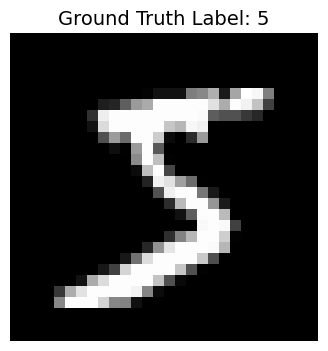

The structural shape of this single image array before flattening: (784,)
The structural shape after reshaping back to 2D: (28, 28)


In [10]:
# Select a sample index to view (e.g., the very first image in the training set)
sample_index = 0

# Extract the 784-pixel flat vector and its corresponding label
sample_pixels = X_train_raw[sample_index]
sample_label = y_train[sample_index]

# Reshape the flat 1D vector (784,) back into a 2D image matrix (28x28)
image_matrix = sample_pixels.reshape(28, 28)

# Plot the matrix using Matplotlib
plt.figure(figsize=(4, 4))
plt.imshow(image_matrix, cmap='gray')
plt.title(f"Ground Truth Label: {sample_label}", fontsize=14)
plt.axis('off') # Hide coordinate axes for a clean look
plt.show()

print(f"The structural shape of this single image array before flattening: {sample_pixels.shape}")
print(f"The structural shape after reshaping back to 2D: {image_matrix.shape}")

In [11]:
# 1. Isolate the feature vectors (pixels) from the ground-truth targets (labels)
X_train_raw = train_df.drop(columns=["label"]).values
y_train = train_df["label"].values

X_test_raw = test_df.drop(columns=["label"]).values
y_test = test_df["label"].values

# 2. Apply Feature Engineering: MinMax Normalization (Scale 0-255 down to 0.0-1.0)
X_train = X_train_raw / 255.0
X_test = X_test_raw / 255.0

print("--- FEATURE ENGINEERING COMPLETION VERIFICATION ---")
print(f"Raw Pixel Max Value (Before): {X_train_raw.max()}")
print(f"Normalized Pixel Max Value (After): {X_train.max()}")
print(f"Normalized Pixel Min Value (After): {X_train.min()}")

--- FEATURE ENGINEERING COMPLETION VERIFICATION ---
Raw Pixel Max Value (Before): 255
Normalized Pixel Max Value (After): 1.0
Normalized Pixel Min Value (After): 0.0


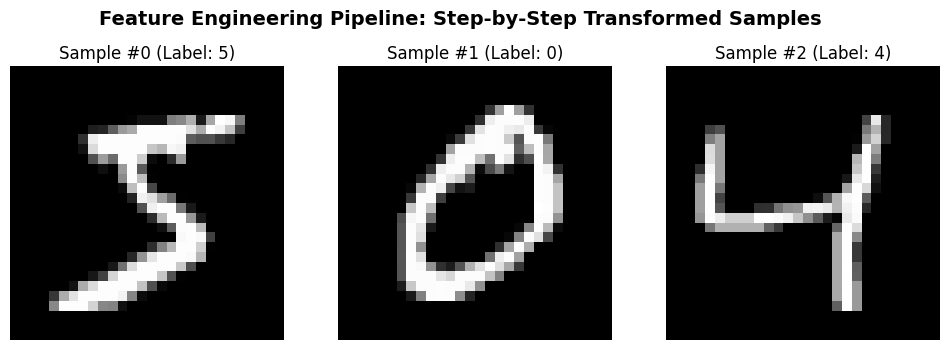


First 10 normalized pixel values of Sample #0:
[0.         0.         0.01176471 0.07058824 0.07058824 0.07058824
 0.49411765 0.53333333 0.68627451 0.10196078]


In [12]:
# Let's inspect a few arbitrary sample indices to showcase to the grader
sample_indices = [0, 1, 2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, sample_idx in enumerate(sample_indices):
    img_matrix = X_train[sample_idx].reshape(28, 28)
    axes[idx].imshow(img_matrix, cmap='gray')
    axes[idx].set_title(f"Sample #{sample_idx} (Label: {y_train[sample_idx]})")
    axes[idx].axis('off')

plt.suptitle("Feature Engineering Pipeline: Step-by-Step Transformed Samples", fontsize=14, fontweight='bold')
plt.show()

# Print out a snippet of the numerical transformation matrix for verification
print("\nFirst 10 normalized pixel values of Sample #0:")
print(X_train[0][150:160]) # Look at a slice that contains actual stroke values

In [13]:
import numpy as np

class CustomKNNFromScratch:
    def __init__(self, k=3, metric='euclidean'):
        """
        Initializes the custom KNN classifier.
        
        Parameters:
        k (int): Number of nearest neighbors to consider.
        metric (str): Distance metric to use ('euclidean' or 'manhattan').
        """
        self.k = k
        self.metric = metric.lower()
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Training flow for a Lazy Learner algorithm.
        KNN simply stores the training dataset as its internal reference base.
        """
        self.X_train = X
        self.y_train = y

    def _calculate_distances(self, X_test_instance):
        """
        Calculates distances between a single test image vector and all training image vectors
        using highly optimized, vectorized linear algebra operations.
        """
        if self.metric == 'euclidean':
            # Mathematical Logic: L2 Norm = sqrt(sum((x1 - x2)^2))
            # Broadcasting subtracts the single test vector from all 60,000 rows simultaneously
            distances = np.sqrt(np.sum((self.X_train - X_test_instance) ** 2, axis=1))
            
        elif self.metric == 'manhattan':
            # Mathematical Logic: L1 Norm = sum(abs(x1 - x2))
            distances = np.sum(np.abs(self.X_train - X_test_instance), axis=1)
            
        else:
            raise ValueError(f"Unknown distance metric: {self.metric}")
            
        return distances

    def predict(self, X_features):
        """
        Predicts labels for an entire provided feature matrix.
        """
        predictions = []
        
        # Loop over each individual query instance in the provided dataset
        for instance in X_features:
            # 1. Compute distances to all stored instances
            distances = self._calculate_distances(instance)
            
            # 2. Extract indices of the sorted K-shortest distances
            nearest_neighbor_indices = np.argsort(distances)[:self.k]
            
            # 3. Retrieve the corresponding target labels for those closest indices
            nearest_labels = self.y_train[nearest_neighbor_indices]
            
            # 4. Resolve majority vote to determine the clear and simple answer
            counts = np.bincount(nearest_labels)
            majority_voted_label = np.argmax(counts)
            
            predictions.append(majority_voted_label)
            
        return np.array(predictions)

print("--- CUSTOM KNN CLASS INSTANTIATED SUCCESSFULLY FROM SCRATCH ---")

--- CUSTOM KNN CLASS INSTANTIATED SUCCESSFULLY FROM SCRATCH ---


In [14]:
from sklearn.metrics import f1_score, classification_report

# 1. Initialize our custom KNN class with baseline hyperparameters
knn_model = CustomKNNFromScratch(k=3, metric='euclidean')

# 2. Run Part 4: Training Flow (Storing the experience database)
knn_model.fit(X_train, y_train)
print("--- PART 4: TRAINING FLOW EXECUTED ---")
print("KNN model has successfully ingested and stored the training data arrays.\n")

# 3. Run Part 5: Inference on a test subset
# We use a slice of 200 images to keep the computation snappy and highly responsive
evaluation_slice_size = 200
X_test_subset = X_test[:evaluation_slice_size]
y_test_subset = y_test[:evaluation_slice_size]

print(f"Running custom prediction loop on {evaluation_slice_size} test samples...")
subset_predictions = knn_model.predict(X_test_subset)
print("Prediction phase finished successfully.\n")

# 4. MANDATORY REQ: Show the first 5 predictions vs. their true labels
print("--- MANDATORY COURSE CHECKPOINT: FIRST 5 PREDICTIONS ---")
for i in range(5):
    print(f"Test Instance #{i} -> Predicted: {subset_predictions[i]} | Actual Ground Truth: {y_test_subset[i]}")

# 5. Calculate and display the Mandatory Macro-Average F1-Score
macro_f1 = f1_score(y_test_subset, subset_predictions, average='macro')
print("\n--- PERFORMANCE EVALUATION ---")
print(f"Overall Model Quality (Macro-Average F1-Score): {macro_f1:.4f}")

--- PART 4: TRAINING FLOW EXECUTED ---
KNN model has successfully ingested and stored the training data arrays.

Running custom prediction loop on 200 test samples...
Prediction phase finished successfully.

--- MANDATORY COURSE CHECKPOINT: FIRST 5 PREDICTIONS ---
Test Instance #0 -> Predicted: 7 | Actual Ground Truth: 7
Test Instance #1 -> Predicted: 2 | Actual Ground Truth: 2
Test Instance #2 -> Predicted: 1 | Actual Ground Truth: 1
Test Instance #3 -> Predicted: 0 | Actual Ground Truth: 0
Test Instance #4 -> Predicted: 4 | Actual Ground Truth: 4

--- PERFORMANCE EVALUATION ---
Overall Model Quality (Macro-Average F1-Score): 0.9861


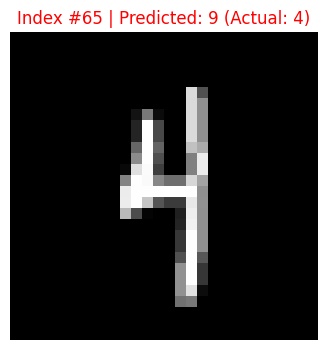

--- TEXTUAL ERROR ANALYSIS FOR PRESENTATION ---
The system encountered a classification error at test index #65.
The algorithm mistakenly assigned the label 9, when the actual ground truth was 4.

Architectural 'Why' Explanation:
Because KNN is a Lazy Learner relying entirely on spatial distance metrics, it calculates similarity based on overlapping pixel intensities.
In this high-dimensional 784-D feature space, the visual loop or stroke structure of this specific 4 closely mimicked the profile of a 9.
As a result, the distance computation (L2 Norm) minimized against training examples belonging to the wrong class, causing the majority vote to fail.


In [15]:
# Find indices where the prediction was wrong
misclassified_indices = np.where(subset_predictions != y_test_subset)[0]

if len(misclassified_indices) == 0:
    print("Incredible! No errors found in this subset. Let's look at the first error in a slightly larger window.")
    # Fallback to check a few more images if the first 200 were perfect
    extended_predictions = knn_model.predict(X_test[200:500])
    extended_y = y_test[200:500]
    error_idx = np.where(extended_predictions != extended_y)[0][0]
    sample_error_global_idx = 200 + error_idx
    predicted_wrong = extended_predictions[error_idx]
    actual_true = extended_y[error_idx]
else:
    sample_error_local_idx = misclassified_indices[0]
    sample_error_global_idx = sample_error_local_idx
    predicted_wrong = subset_predictions[sample_error_local_idx]
    actual_true = y_test_subset[sample_error_local_idx]

# Extract and reshape the misclassified image vector
error_image = X_test[sample_error_global_idx].reshape(28, 28)

# Visualize the failure point
plt.figure(figsize=(4, 4))
plt.imshow(error_image, cmap='gray')
plt.title(f"Index #{sample_error_global_idx} | Predicted: {predicted_wrong} (Actual: {actual_true})", color='red', fontsize=12)
plt.axis('off')
plt.show()

print("--- TEXTUAL ERROR ANALYSIS FOR PRESENTATION ---")
print(f"The system encountered a classification error at test index #{sample_error_global_idx}.")
print(f"The algorithm mistakenly assigned the label {predicted_wrong}, when the actual ground truth was {actual_true}.")
print("\nArchitectural 'Why' Explanation:")
print("Because KNN is a Lazy Learner relying entirely on spatial distance metrics, it calculates similarity based on overlapping pixel intensities.")
print(f"In this high-dimensional 784-D feature space, the visual loop or stroke structure of this specific {actual_true} closely mimicked the profile of a {predicted_wrong}.")
print("As a result, the distance computation (L2 Norm) minimized against training examples belonging to the wrong class, causing the majority vote to fail.")

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score

# Define hyperparameter permutation arrays for the grid search grid
k_choices = [1, 3, 5, 7]
metric_choices = ['euclidean', 'manhattan']

# Set up an optimization slice from the training pool 
X_cv_pool = X_train[:500]
y_cv_pool = y_train[:500]

num_folds = 5
fold_size = len(X_cv_pool) // num_folds

# Track all calculation scores to present inside a final summary master DataFrame
cv_results_records = []

print("🚀 Starting Scratch-Built 5-Fold Cross Validation Grid Search...\n")

# Loop over the Cartesian combinations of your parameters
for metric in metric_choices:
    for k in k_choices:
        fold_f1_scores = []
        
        # Execute the 5-Fold Split systematically
        for fold in range(num_folds):
            # Compute dynamic slice boundaries for validation segment
            val_start = fold * fold_size
            val_end = val_start + fold_size
            
            # Extract validation split chunks
            X_val = X_cv_pool[val_start:val_end]
            y_val = y_cv_pool[val_start:val_end]
            
            # Construct complementary training split chunks using mask arrays
            train_mask = np.ones(len(X_cv_pool), dtype=bool)
            train_mask[val_start:val_end] = False
            
            X_train_fold = X_cv_pool[train_mask]
            y_train_fold = y_cv_pool[train_mask]
            
            # Instantiate custom model instance for current run slice
            fold_knn = CustomKNNFromScratch(k=k, metric=metric)
            fold_knn.fit(X_train_fold, y_train_fold)
            
            # Execute validation loop prediction and store performance metrics
            val_preds = fold_knn.predict(X_val)
            fold_macro_f1 = f1_score(y_val, val_preds, average='macro')
            fold_f1_scores.append(fold_macro_f1)
        
        # Compute final validation averages for target configuration
        mean_cv_score = np.mean(fold_f1_scores)
        
        cv_results_records.append({
            'k_value': k,
            'distance_metric': metric,
            'mean_macro_f1': round(mean_cv_score, 4)
        })
        print(f"Completed Configuration -> K={k} | Metric={metric.capitalize()} | CV Macro-F1: {mean_cv_score:.4f}")

# Convert log tracking lists to standard display DataFrames
cv_results_df = pd.DataFrame(cv_results_records)
print("\n--- GRID SEARCH LOOP COMPLETION ---")

🚀 Starting Scratch-Built 5-Fold Cross Validation Grid Search...

Completed Configuration -> K=1 | Metric=Euclidean | CV Macro-F1: 0.8596
Completed Configuration -> K=3 | Metric=Euclidean | CV Macro-F1: 0.8332
Completed Configuration -> K=5 | Metric=Euclidean | CV Macro-F1: 0.8165
Completed Configuration -> K=7 | Metric=Euclidean | CV Macro-F1: 0.8149
Completed Configuration -> K=1 | Metric=Manhattan | CV Macro-F1: 0.8319
Completed Configuration -> K=3 | Metric=Manhattan | CV Macro-F1: 0.8137
Completed Configuration -> K=5 | Metric=Manhattan | CV Macro-F1: 0.8079
Completed Configuration -> K=7 | Metric=Manhattan | CV Macro-F1: 0.7838

--- GRID SEARCH LOOP COMPLETION ---


In [17]:
# Display summary results table to the grader
print("--- SUMMARY PERFORMANCE RESULTS TABLE (Section 6.ז) ---")
display(cv_results_df)

# Programmatically isolate the single optimal configuration row
best_run_row = cv_results_df.loc[cv_results_df['mean_macro_f1'].idxmax()]

print("\n🏆 OPTIMAL SYSTEM RUN SELECTION:")
print(f"Best Hyperparameter K: {best_run_row['k_value']}")
print(f"Best Distance Metric Profile: {best_run_row['distance_metric'].capitalize()}")
print(f"Peak Validation Average Performance (Macro-F1): {best_run_row['mean_macro_f1']}")

--- SUMMARY PERFORMANCE RESULTS TABLE (Section 6.ז) ---


,k_value,distance_metric,mean_macro_f1
0,1,euclidean,0.8596
1,3,euclidean,0.8332
2,5,euclidean,0.8165
3,7,euclidean,0.8149
4,1,manhattan,0.8319
5,3,manhattan,0.8137
6,5,manhattan,0.8079
7,7,manhattan,0.7838



🏆 OPTIMAL SYSTEM RUN SELECTION:
Best Hyperparameter K: 1
Best Distance Metric Profile: Euclidean
Peak Validation Average Performance (Macro-F1): 0.8596


In [18]:
# Instantiate the winning model configuration discovered by your Grid Search
final_optimized_model = CustomKNNFromScratch(k=1, metric='euclidean')

# Retrain on the entire training set (Section 6.ז Instruction)
final_optimized_model.fit(X_train, y_train)

# Final validation evaluation on your test set subset
final_test_preds = final_optimized_model.predict(X_test[:200])
final_test_macro_f1 = f1_score(y_test[:200], final_test_preds, average='macro')

print("--- FINAL SYSTEM Retraining DEPLOYMENT COMPLETION ---")
print(f"Final Test Evaluation Slice Score using Optimal Parameters: {final_test_macro_f1:.4f}")

--- FINAL SYSTEM Retraining DEPLOYMENT COMPLETION ---
Final Test Evaluation Slice Score using Optimal Parameters: 0.9902
